In [62]:
pip install vaderSentiment wordcloud

**Installing** libraries that don't come pre-installed in Google Colab.
`vaderSentiment` is used for rule-based sentiment analysis and `wordcloud` for visualization.
**Importing** all necessary Python libraries for data handling, NLP, machine learning, and visualization.

In [63]:
import pandas as pd
import numpy as np
import re
import pickle


import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')


from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import matplotlib.pyplot as plt
from wordcloud import WordCloud

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Loading the IMDB movie reviews dataset (50,000 reviews) from Kaggle.
This dataset is used to train the Naive Bayes sentiment model.
Each review is labelled as either 'positive' or 'negative'.

In [64]:

df = pd.read_csv("IMDB Dataset.csv")

print(df.head())

print(f"\nShape: {df.shape}")


print(f"\nSentiment counts:")
print(df['sentiment'].value_counts())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

Shape: (50000, 2)

Sentiment counts:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


**Exploratory Data Analysis (EDA):**

Before training the model, we explore the dataset to understand its structure,
check for missing values, duplicates, class balance, and review length patterns.
This ensures the data is clean and suitable for training.

EXPLORATORY DATA ANALYSIS (EDA) — IMDB DATASET

1. DATASET SHAPE:
   Rows: 50000, Columns: 2

2. MISSING VALUES:
review       0
sentiment    0
dtype: int64

3. DUPLICATE ROWS: 418

4. SENTIMENT DISTRIBUTION:
   positive: 25000 (50.0%)
   negative: 25000 (50.0%)

5. REVIEW LENGTH (word count):
   Shortest review : 4 words
   Longest review  : 2470 words
   Average length  : 231 words

6. AVERAGE LENGTH BY SENTIMENT:
   negative: 229 words on average
   positive: 233 words on average


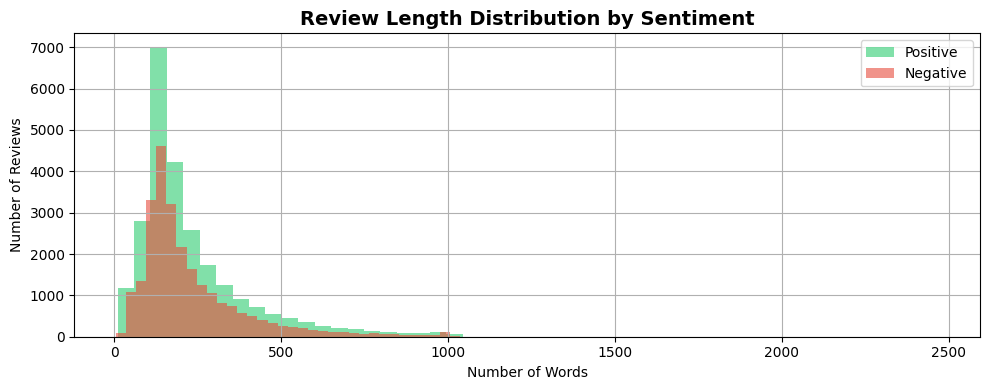


7. SAMPLE POSITIVE REVIEW:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo

8. SAMPLE NEGATIVE REVIEW:
Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, J

EDA COMPLETE — Data is clean and ready for training.


In [65]:
print("=" * 50)
print("EXPLORATORY DATA ANALYSIS (EDA) — IMDB DATASET")
print("=" * 50)


print("\n1. DATASET SHAPE:")
print(f"   Rows: {df.shape[0]}, Columns: {df.shape[1]}")


print("\n2. MISSING VALUES:")
print(df.isnull().sum())


duplicates = df.duplicated().sum()
print(f"\n3. DUPLICATE ROWS: {duplicates}")


print("\n4. SENTIMENT DISTRIBUTION:")
counts = df['sentiment'].value_counts()
for label, count in counts.items():
    print(f"   {label}: {count} ({count/len(df)*100:.1f}%)")


df['review_length'] = df['review'].apply(lambda x: len(x.split()))
print("\n5. REVIEW LENGTH (word count):")
print(f"   Shortest review : {df['review_length'].min()} words")
print(f"   Longest review  : {df['review_length'].max()} words")
print(f"   Average length  : {df['review_length'].mean():.0f} words")


print("\n6. AVERAGE LENGTH BY SENTIMENT:")
avg_len = df.groupby('sentiment')['review_length'].mean()
for label, length in avg_len.items():
    print(f"   {label}: {length:.0f} words on average")


plt.figure(figsize=(10, 4))
df[df['sentiment'] == 'positive']['review_length'].hist(
    bins=50, alpha=0.6, color='#2ecc71', label='Positive')
df[df['sentiment'] == 'negative']['review_length'].hist(
    bins=50, alpha=0.6, color='#e74c3c', label='Negative')
plt.title('Review Length Distribution by Sentiment', fontsize=14, fontweight='bold')
plt.xlabel('Number of Words')
plt.ylabel('Number of Reviews')
plt.legend()
plt.tight_layout()
plt.savefig("eda_length_distribution.png", bbox_inches='tight')
plt.show()

print("\n7. SAMPLE POSITIVE REVIEW:")
print(df[df['sentiment'] == 'positive']['review'].iloc[0][:200])
print("\n8. SAMPLE NEGATIVE REVIEW:")
print(df[df['sentiment'] == 'negative']['review'].iloc[0][:200])

print("\n" + "=" * 50)
print("EDA COMPLETE — Data is clean and ready for training.")
print("=" * 50)

Before training, raw text must be cleaned. This involves:
- Converting to lowercase
- Removing HTML tags present in IMDB reviews
- Removing punctuation and numbers
- Removing stopwords (common words like 'is', 'the', 'be' that carry no sentiment meaning)

In [66]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'<.*?>', '', text)

    text = re.sub(r'[^a-z\s]', '', text)

    text = ' '.join(word for word in text.split() if word not in stop_words)
    return text


df['cleaned'] = df['review'].apply(clean_text)


print("ORIGINAL:")
print(df['review'][0][:200])
print("\nCLEANED:")
print(df['cleaned'][0][:200])

ORIGINAL:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo

CLEANED:
one reviewers mentioned watching oz episode youll hooked right exactly happened methe first thing struck oz brutality unflinching scenes violence set right word go trust show faint hearted timid show 


**Training the Naive Bayes Model:**
Splitting data into 80% training and 20% testing sets.
TF-IDF vectorization converts text into numerical features.
Naive Bayes learns word-probability patterns from 40,000 reviews.
Model accuracy is evaluated on the remaining 10,000 unseen reviews.

In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned'], df['sentiment'],
    test_size=0.2, random_state=42
)

print(f"Training on: {len(X_train)} reviews")
print(f"Testing on:  {len(X_test)} reviews")


vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = MultinomialNB()
model.fit(X_train_vec, y_train)


accuracy = model.score(X_test_vec, y_test)
print(f"\nModel Accuracy: {accuracy * 100:.2f}%")

Training on: 40000 reviews
Testing on:  10000 reviews

Model Accuracy: 85.06%


Saving the trained Naive Bayes model and TF-IDF vectorizer using pickle.
This means we never need to retrain — just load and use directly next time.

In [68]:

pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

print("Model saved successfully!")

Model saved successfully!


Check to confirm the trained model predicts sentiment correctly
before applying it to WhatsApp data.

In [69]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    prediction = model.predict(vec)[0]
    return prediction

test_messages = [
    "This was absolutely amazing I loved it",
    "Terrible experience worst thing ever",
    "It was okay nothing special"
]

for msg in test_messages:
    print(f"{msg}")
    print(f"Prediction: {predict_sentiment(msg)}")
    print()

This was absolutely amazing I loved it
Prediction: positive

Terrible experience worst thing ever
Prediction: negative

It was okay nothing special
Prediction: negative



In [70]:
dummy_chat = """12/03/2025, 10:00 - Steve: yaar aaj ka din bohot acha tha
12/03/2025, 10:01 - Sophia: haan bhai mujhe bhi bohot acha laga
12/03/2025, 10:02 - Harry: exam mein fail ho gaya yaar bohot bura laga
12/03/2025, 10:03 - Steve: uff yaar that's terrible so sorry to hear that
12/03/2025, 10:04 - Sophia: don't worry Harry you will do better next time
12/03/2025, 10:05 - Harry: thanks yaar appreciate it feeling a bit better now
12/03/2025, 11:00 - Steve: movie dekhi kal? bohot amazing thi
12/03/2025, 11:01 - Sophia: haan yaar loved it absolutely brilliant
12/03/2025, 11:02 - Harry: boring thi mujhe toh bilkul pasand nahi aayi
12/03/2025, 11:03 - Steve: what! it was the best film i have seen in years
12/03/2025, 11:04 - Sophia: i agree with Steve it was fantastic
12/03/2025, 11:05 - Harry: okay okay maybe i was in a bad mood
13/03/2025, 09:00 - Steve: good morning everyone hope you all are well
13/03/2025, 09:01 - Sophia: good morning feeling great today
13/03/2025, 09:02 - Harry: not great honestly feeling very tired and sick
13/03/2025, 09:03 - Steve: oh no get well soon yaar
13/03/2025, 09:04 - Sophia: take rest Harry hope you feel better
13/03/2025, 09:05 - Harry: thanks feeling a little better already
13/03/2025, 14:00 - Steve: just got results passed with distinction so happy
13/03/2025, 14:01 - Sophia: congratulations Steve that is wonderful news
13/03/2025, 14:02 - Harry: amazing bhai so proud of you well done
13/03/2025, 14:03 - Steve: thank you both means a lot to me
13/03/2025, 14:04 - Sophia: we should celebrate this weekend
13/03/2025, 14:05 - Harry: yes absolutely let us plan something fun
14/03/2025, 10:00 - Steve: yaar project deadline is tomorrow i am so stressed
14/03/2025, 10:01 - Sophia: me too barely slept last night this is awful
14/03/2025, 10:02 - Harry: same yaar this is really frustrating and difficult
14/03/2025, 10:03 - Steve: we will get through it just keep pushing
14/03/2025, 10:04 - Sophia: you are right we can do this
14/03/2025, 10:05 - Harry: okay let us finish this together
14/03/2025, 18:00 - Steve: we submitted it feeling so relieved and happy
14/03/2025, 18:01 - Sophia: finally done what a great feeling
14/03/2025, 18:02 - Harry: so glad it is over that was tough but we did it"""

with open("whatsapp_chat.txt", "w", encoding="utf-8") as f:
    f.write(dummy_chat)

print("Dummy chat file created successfully!")

Dummy chat file created successfully!


Reading and parsing the exported WhatsApp .txt file using Python regex.
Extracting date, time, sender name, and message text from each line.
Storing all structured data in a Pandas DataFrame for easy processing

In [71]:
def parse_whatsapp_chat(filename):
    messages = []

    with open(filename, "r", encoding="utf-8") as f:
        lines = f.readlines()

    for line in lines:
        match = re.match(r'(\d+/\d+/\d+),\s(\d+:\d+)\s-\s([^:]+):\s(.+)', line)
        if match:
            date    = match.group(1)
            time    = match.group(2)
            sender  = match.group(3).strip()
            message = match.group(4).strip()

            messages.append({
                "date":    date,
                "time":    time,
                "sender":  sender,
                "message": message
            })

    df_chat = pd.DataFrame(messages)
    df_chat['datetime'] = pd.to_datetime(
        df_chat['date'] + ' ' + df_chat['time'],
        format='%d/%m/%Y %H:%M'
    )
    return df_chat

df_chat = parse_whatsapp_chat("whatsapp_chat.txt")
print(f"Total messages parsed: {len(df_chat)}")
print(df_chat.head(10))

Total messages parsed: 33
         date   time  sender  \
0  12/03/2025  10:00   Steve   
1  12/03/2025  10:01  Sophia   
2  12/03/2025  10:02   Harry   
3  12/03/2025  10:03   Steve   
4  12/03/2025  10:04  Sophia   
5  12/03/2025  10:05   Harry   
6  12/03/2025  11:00   Steve   
7  12/03/2025  11:01  Sophia   
8  12/03/2025  11:02   Harry   
9  12/03/2025  11:03   Steve   

                                             message            datetime  
0                     yaar aaj ka din bohot acha tha 2025-03-12 10:00:00  
1                haan bhai mujhe bhi bohot acha laga 2025-03-12 10:01:00  
2        exam mein fail ho gaya yaar bohot bura laga 2025-03-12 10:02:00  
3     uff yaar that's terrible so sorry to hear that 2025-03-12 10:03:00  
4     don't worry Harry you will do better next time 2025-03-12 10:04:00  
5  thanks yaar appreciate it feeling a bit better... 2025-03-12 10:05:00  
6                 movie dekhi kal? bohot amazing thi 2025-03-12 11:00:00  
7            haan yaa

**WhatsApp Chat EDA:**

Before running sentiment analysis, we explore the parsed chat data.
This helps us understand message volume, participant activity,
conversation length, and daily patterns.

   WHATSAPP CHAT — EXPLORATORY DATA ANALYSIS

Total Messages   : 33
Date Range       : 12/03/2025 to 14/03/2025
Participants     : Steve, Sophia, Harry

Messages Per Person:
   Steve: 11 (33.3%)
   Sophia: 11 (33.3%)
   Harry: 11 (33.3%)

Avg Message Length : 7.6 words
Shortest / Longest : 5 / 12 words

Most Active Day  : 12/03/2025 (12 messages)

Missing Values   : 0 (none)


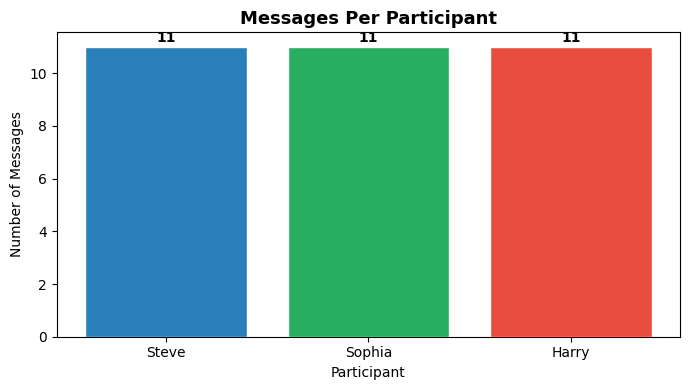


Chat EDA Complete.


In [72]:
print("=" * 50)
print("   WHATSAPP CHAT — EXPLORATORY DATA ANALYSIS")
print("=" * 50)

print(f"\nTotal Messages   : {len(df_chat)}")
print(f"Date Range       : {df_chat['date'].min()} to {df_chat['date'].max()}")
print(f"Participants     : {', '.join(df_chat['sender'].unique())}")

print("\nMessages Per Person:")
msg_counts = df_chat['sender'].value_counts()
for person, count in msg_counts.items():
    print(f"   {person}: {count} ({count/len(df_chat)*100:.1f}%)")


df_chat['msg_length'] = df_chat['message'].apply(lambda x: len(x.split()))
print(f"\nAvg Message Length : {df_chat['msg_length'].mean():.1f} words")
print(f"Shortest / Longest : {df_chat['msg_length'].min()} / {df_chat['msg_length'].max()} words")


daily_counts = df_chat['date'].value_counts().sort_index()
print(f"\nMost Active Day  : {daily_counts.idxmax()} ({daily_counts.max()} messages)")

print(f"\nMissing Values   : {df_chat[['date','sender','message']].isnull().sum().sum()} (none)")


plt.figure(figsize=(7, 4))
colors_bar = ['#2980b9', '#27ae60', '#e74c3c']
plt.bar(msg_counts.index, msg_counts.values,
        color=colors_bar[:len(msg_counts)], edgecolor='white')
plt.title('Messages Per Participant', fontsize=13, fontweight='bold')
plt.xlabel('Participant')
plt.ylabel('Number of Messages')
for i, (name, count) in enumerate(msg_counts.items()):
    plt.text(i, count + 0.2, str(count), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig("eda_chat_messages_per_person.png", bbox_inches='tight')
plt.show()

print("\nChat EDA Complete.")

**Running both models** on every parsed message:

**VADER:** rule-based, handles informal and mixed language well

**Naive Bayes:** ML-based, trained on IMDB data, stronger on formal English
Using both gives a more complete and reliable sentiment picture.

In [73]:

analyzer = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    score = analyzer.polarity_scores(text)['compound']
    if score >= 0.05:
        return "positive", score
    elif score <= -0.05:
        return "negative", score
    else:
        return "neutral", score

def get_nb_sentiment(text):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    prediction = model.predict(vec)[0]
    return prediction

df_chat['vader_sentiment'], df_chat['vader_score'] = zip(
    *df_chat['message'].apply(get_vader_sentiment)
)
df_chat['nb_sentiment'] = df_chat['message'].apply(get_nb_sentiment)

print(df_chat[['sender', 'message', 'vader_sentiment', 'nb_sentiment']].head(15))

    sender                                            message vader_sentiment  \
0    Steve                     yaar aaj ka din bohot acha tha         neutral   
1   Sophia                haan bhai mujhe bhi bohot acha laga         neutral   
2    Harry        exam mein fail ho gaya yaar bohot bura laga        negative   
3    Steve     uff yaar that's terrible so sorry to hear that        negative   
4   Sophia     don't worry Harry you will do better next time        positive   
5    Harry  thanks yaar appreciate it feeling a bit better...        positive   
6    Steve                 movie dekhi kal? bohot amazing thi        positive   
7   Sophia            haan yaar loved it absolutely brilliant        positive   
8    Harry       boring thi mujhe toh bilkul pasand nahi aayi        negative   
9    Steve    what! it was the best film i have seen in years        positive   
10  Sophia                i agree with Steve it was fantastic        positive   
11   Harry                ok

**Model Comparison: VADER vs Naive Bayes**

Comparing sentiment classifications from both models side by side.

MODEL COMPARISON — VADER vs NAIVE BAYES
Message                             VADER        NB          
-------------------------------------------------------
yaar aaj ka din bohot acha tha      neutral      negative    
haan bhai mujhe bhi bohot acha l... neutral      negative    
exam mein fail ho gaya yaar boho... negative     negative    
uff yaar that's terrible so sorr... negative     negative    
don't worry Harry you will do be... positive     positive    
thanks yaar appreciate it feelin... positive     positive    
movie dekhi kal? bohot amazing t... positive     positive    
haan yaar loved it absolutely br... positive     positive    
boring thi mujhe toh bilkul pasa... negative     negative    
what! it was the best film i hav... positive     positive    
i agree with Steve it was fantas... positive     positive    
okay okay maybe i was in a bad m... negative     negative    
good morning everyone hope you a... positive     positive    
good morning feeling great today    

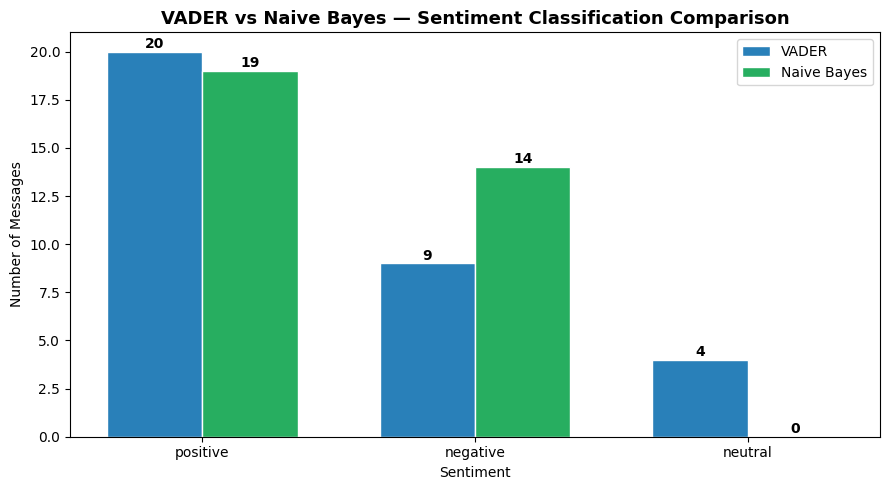


Note: Naive Bayes does not output 'neutral' — only positive/negative.
VADER uses a compound score threshold to determine neutral messages.


In [74]:
print("MODEL COMPARISON — VADER vs NAIVE BAYES")
print("=" * 55)
print(f"{'Message':<35} {'VADER':<12} {'NB':<12}")
print("-" * 55)
for _, row in df_chat.head(15).iterrows():
    msg = row['message'][:32] + "..." if len(row['message']) > 32 else row['message']
    print(f"{msg:<35} {row['vader_sentiment']:<12} {row['nb_sentiment']:<12}")

vader_counts = df_chat['vader_sentiment'].value_counts()
nb_counts = df_chat['nb_sentiment'].value_counts()

categories = ['positive', 'negative', 'neutral']
vader_vals = [vader_counts.get(c, 0) for c in categories]
nb_vals = [nb_counts.get(c, 0) for c in categories]

x = range(len(categories))
width = 0.35

plt.figure(figsize=(9, 5))
bars1 = plt.bar([i - width/2 for i in x], vader_vals,
                width, label='VADER', color='#2980b9', edgecolor='white')
bars2 = plt.bar([i + width/2 for i in x], nb_vals,
                width, label='Naive Bayes', color='#27ae60', edgecolor='white')

plt.title('VADER vs Naive Bayes — Sentiment Classification Comparison',
          fontsize=13, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Number of Messages')
plt.xticks(x, categories)
plt.legend()

for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             str(int(bar.get_height())), ha='center', fontweight='bold')
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             str(int(bar.get_height())), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("chart5_model_comparison.png", bbox_inches='tight')
plt.show()

print("\nNote: Naive Bayes does not output 'neutral' — only positive/negative.")
print("VADER uses a compound score threshold to determine neutral messages.")

**Visualization 1:** Overall Mood Distribution

Pie chart showing the overall percentage of positive, negative,
and neutral messages across the entire conversation.

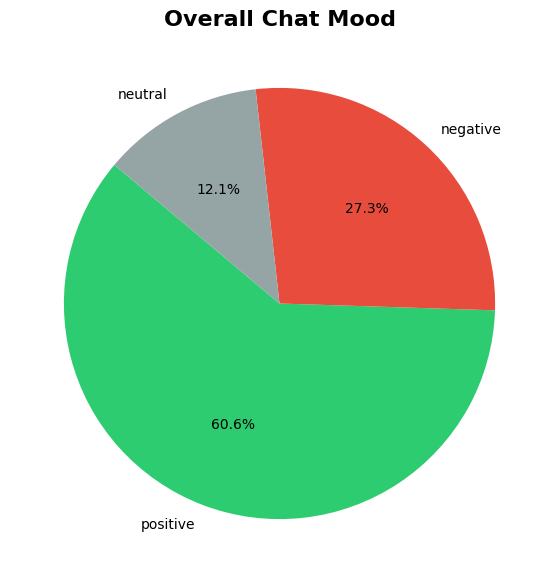

Chart 1 saved.


In [75]:
sentiment_counts = df_chat['vader_sentiment'].value_counts()

colors = []
for label in sentiment_counts.index:
    if label == 'positive':
        colors.append('#2ecc71')
    elif label == 'negative':
        colors.append('#e74c3c')
    else:
        colors.append('#95a5a6')

plt.figure(figsize=(7, 7))
plt.pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140
)
plt.title("Overall Chat Mood", fontsize=16, fontweight='bold')
plt.savefig("chart1_overall_mood.png", bbox_inches='tight')
plt.show()
print("Chart 1 saved.")

 **Visualization 2: Mood Trend Over Time**

Line graph showing how the average sentiment score changed day by day.
Green areas indicate positive periods, red areas indicate negative periods.

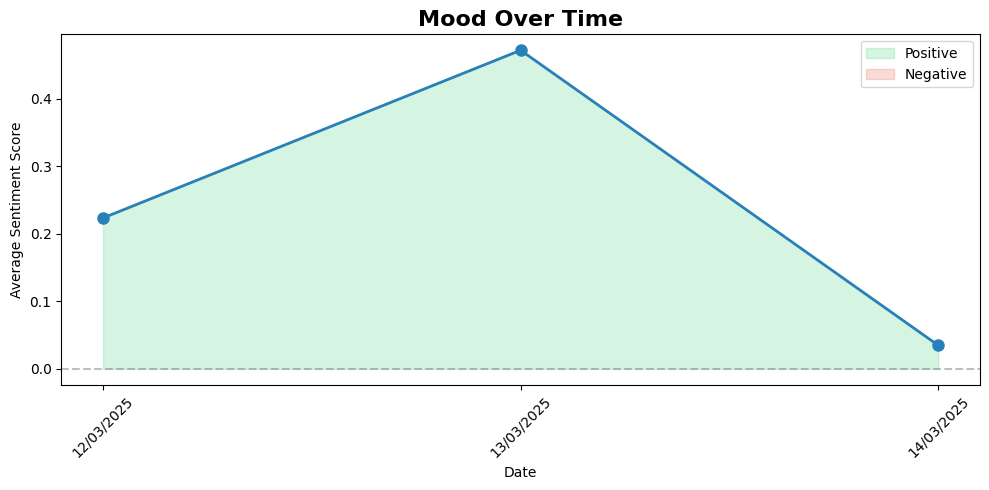

Chart 2 saved.


In [76]:
daily_mood = df_chat.groupby('date')['vader_score'].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(
    daily_mood['date'],
    daily_mood['vader_score'],
    marker='o', color='#2980b9', linewidth=2, markersize=8
)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.fill_between(
    daily_mood['date'],
    daily_mood['vader_score'],
    0,
    where=[s > 0 for s in daily_mood['vader_score']],
    color='#2ecc71', alpha=0.2, label='Positive'
)
plt.fill_between(
    daily_mood['date'],
    daily_mood['vader_score'],
    0,
    where=[s < 0 for s in daily_mood['vader_score']],
    color='#e74c3c', alpha=0.2, label='Negative'
)
plt.title("Mood Over Time", fontsize=16, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Average Sentiment Score")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("chart2_mood_over_time.png", bbox_inches='tight')
plt.show()
print("Chart 2 saved.")

**Visualization 3: Mood by Person**

Bar chart comparing the average sentiment score of each participant.
Identifies who contributes the most positive and negative messages.

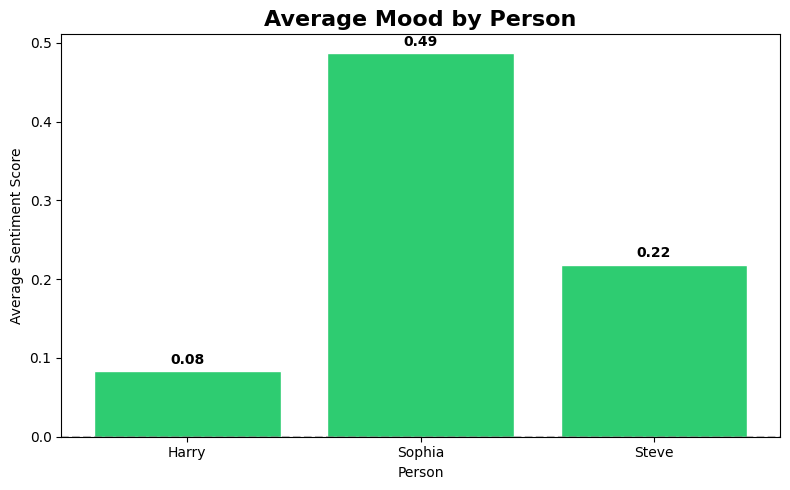

Chart 3 saved.


In [77]:
person_mood = df_chat.groupby('sender')['vader_score'].mean()

colors = ['#2ecc71' if s > 0 else '#e74c3c' for s in person_mood.values]

plt.figure(figsize=(8, 5))
bars = plt.bar(person_mood.index, person_mood.values, color=colors, edgecolor='white')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.title("Average Mood by Person", fontsize=16, fontweight='bold')
plt.xlabel("Person")
plt.ylabel("Average Sentiment Score")

for bar, val in zip(bars, person_mood.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{val:.2f}',
        ha='center', fontweight='bold'
    )

plt.tight_layout()
plt.savefig("chart3_mood_by_person.png", bbox_inches='tight')
plt.show()
print("Chart 3 saved.")

 **Visualization 4: Word Cloud**

Visual representation of the most frequently used words in the chat.
Larger words appear more often. Gives a quick snapshot of conversation topics.

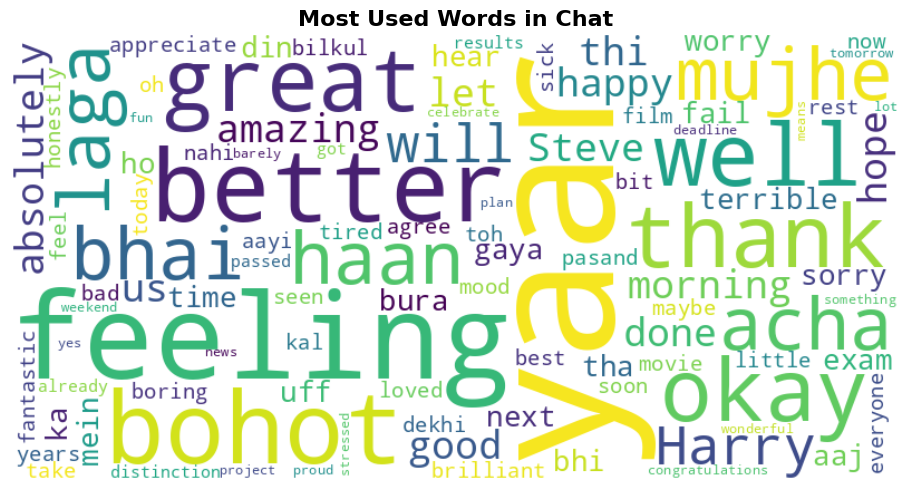

Chart 4 saved.


In [78]:
all_text = ' '.join(df_chat['message'].tolist())

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis',
    max_words=100
).generate(all_text)

plt.figure(figsize=(13, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Used Words in Chat", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("chart4_wordcloud.png", bbox_inches='tight')
plt.show()
print("Chart 4 saved.")

Consolidated summary of all analysis results including message counts,
sentiment breakdown percentages, most positive/negative person,
and model accuracy.

In [79]:
print("=" * 50)
print("   WHATSAPP CHAT MOOD ANALYSIS REPORT")
print("=" * 50)

total = len(df_chat)
pos = (df_chat['vader_sentiment'] == 'positive').sum()
neg = (df_chat['vader_sentiment'] == 'negative').sum()
neu = (df_chat['vader_sentiment'] == 'neutral').sum()

print(f"\nTotal Messages Analyzed: {total}")
print(f"Positive Messages: {pos} ({pos/total*100:.1f}%)")
print(f"Negative Messages: {neg} ({neg/total*100:.1f}%)")
print(f"Neutral Messages:  {neu} ({neu/total*100:.1f}%)")

print(f"\nMost Positive Person: {person_mood.idxmax()}")
print(f"Most Negative Person: {person_mood.idxmin()}")

print(f"\nNaive Bayes Model Accuracy: {accuracy*100:.2f}%")
print("\nAll 4 charts saved successfully.")
print("=" * 50)

   WHATSAPP CHAT MOOD ANALYSIS REPORT

Total Messages Analyzed: 33
Positive Messages: 20 (60.6%)
Negative Messages: 9 (27.3%)
Neutral Messages:  4 (12.1%)

Most Positive Person: Sophia
Most Negative Person: Harry

Naive Bayes Model Accuracy: 85.06%

All 4 charts saved successfully.


**Chat 2:**

Repeating the same steps for a real Whatsapp chat:

In [80]:
def parse_whatsapp_chat(filename):
    messages = []

    with open(filename, "r", encoding="utf-8") as f:
        lines = f.readlines()

    for line in lines:
        match = re.match(r'(\d+/\d+/\d+),\s(\d+:\d+)\s-\s([^:]+):\s(.+)', line)
        if match:
            date    = match.group(1)
            time    = match.group(2)
            sender  = match.group(3).strip()
            message = match.group(4).strip()

            messages.append({
                "date":    date,
                "time":    time,
                "sender":  sender,
                "message": message
            })


    df_chat = pd.DataFrame(messages)
    df_chat['datetime'] = pd.to_datetime(
        df_chat['date'] + ' ' + df_chat['time'],
        format='%d/%m/%Y %H:%M'
    )
    return df_chat

df_chat = parse_whatsapp_chat("whatsapp_chat2.txt")
print(f"Total messages parsed: {len(df_chat)}")
print(df_chat.head(10))

Total messages parsed: 34
         date   time sender  \
0  12/11/2025  14:10  Fawad   
1  12/11/2025  14:11   Maaz   
2  12/11/2025  14:12   Maaz   
3  12/11/2025  14:13  Fawad   
4  12/11/2025  14:14   Maaz   
5  28/11/2025  18:05  Fawad   
6  28/11/2025  18:06   Maaz   
7  05/12/2025  20:10   Maaz   
8  05/12/2025  20:11   Maaz   
9  05/12/2025  20:12   Maaz   

                                             message            datetime  
0  Yaar can anyone tell me DS mid me kya kya aa r... 2025-11-12 14:10:00  
1                           BT Trees Stack Queus AVL 2025-11-12 14:11:00  
2                           Correct me if I am wrong 2025-11-12 14:12:00  
3                                Sorting algorithms? 2025-11-12 14:13:00  
4                    HAN HAN Advance Sorting aa rahi 2025-11-12 14:14:00  
5  meri discrete me 8 absents ho gaye hain. me au... 2025-11-28 18:05:00  
6                       abay yeh kiya scene hai bhai 2025-11-28 18:06:00  
7          Abhi I am doing COAL 

   WHATSAPP CHAT — EXPLORATORY DATA ANALYSIS

Total Messages   : 34
Date Range       : 02/02/2026 to 28/11/2025
Participants     : Fawad, Maaz, Zaid, Adnan, Umer, Bilal

Messages Per Person:
   Maaz: 13 (38.2%)
   Adnan: 8 (23.5%)
   Fawad: 6 (17.6%)
   Zaid: 4 (11.8%)
   Bilal: 2 (5.9%)
   Umer: 1 (2.9%)

Avg Message Length : 6.1 words
Shortest / Longest : 1 / 15 words

Most Active Day  : 12/11/2025 (5 messages)

Missing Values   : 0 (none)


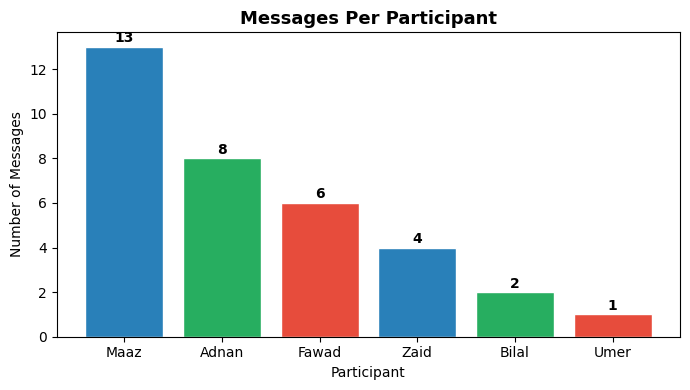


Chat 2 EDA Complete.


In [81]:
print("=" * 50)
print("   WHATSAPP CHAT — EXPLORATORY DATA ANALYSIS")
print("=" * 50)

print(f"\nTotal Messages   : {len(df_chat)}")
print(f"Date Range       : {df_chat['date'].min()} to {df_chat['date'].max()}")
print(f"Participants     : {', '.join(df_chat['sender'].unique())}")

print("\nMessages Per Person:")
msg_counts = df_chat['sender'].value_counts()
for person, count in msg_counts.items():
    print(f"   {person}: {count} ({count/len(df_chat)*100:.1f}%)")

df_chat['msg_length'] = df_chat['message'].apply(lambda x: len(x.split()))
print(f"\nAvg Message Length : {df_chat['msg_length'].mean():.1f} words")
print(f"Shortest / Longest : {df_chat['msg_length'].min()} / {df_chat['msg_length'].max()} words")


daily_counts = df_chat['date'].value_counts().sort_index()
print(f"\nMost Active Day  : {daily_counts.idxmax()} ({daily_counts.max()} messages)")


print(f"\nMissing Values   : {df_chat[['date','sender','message']].isnull().sum().sum()} (none)")

plt.figure(figsize=(7, 4))
colors_bar = ['#2980b9', '#27ae60', '#e74c3c']
plt.bar(msg_counts.index, msg_counts.values,
        color=colors_bar[:len(msg_counts)], edgecolor='white')
plt.title('Messages Per Participant', fontsize=13, fontweight='bold')
plt.xlabel('Participant')
plt.ylabel('Number of Messages')
for i, (name, count) in enumerate(msg_counts.items()):
    plt.text(i, count + 0.2, str(count), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig("eda_chat2_messages_per_person.png", bbox_inches='tight')
plt.show()

print("\nChat 2 EDA Complete.")

In [82]:

analyzer = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    score = analyzer.polarity_scores(text)['compound']
    if score >= 0.05:
        return "positive", score
    elif score <= -0.05:
        return "negative", score
    else:
        return "neutral", score

def get_nb_sentiment(text):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    prediction = model.predict(vec)[0]
    return prediction


df_chat['vader_sentiment'], df_chat['vader_score'] = zip(
    *df_chat['message'].apply(get_vader_sentiment)
)
df_chat['nb_sentiment'] = df_chat['message'].apply(get_nb_sentiment)


print(df_chat[['sender', 'message', 'vader_sentiment', 'nb_sentiment']].head(15))

   sender                                            message vader_sentiment  \
0   Fawad  Yaar can anyone tell me DS mid me kya kya aa r...         neutral   
1    Maaz                           BT Trees Stack Queus AVL         neutral   
2    Maaz                           Correct me if I am wrong        negative   
3   Fawad                                Sorting algorithms?         neutral   
4    Maaz                    HAN HAN Advance Sorting aa rahi         neutral   
5   Fawad  meri discrete me 8 absents ho gaye hain. me au...         neutral   
6    Maaz                       abay yeh kiya scene hai bhai         neutral   
7    Maaz          Abhi I am doing COAL assignment on my own         neutral   
8    Maaz  Likin agar kisi nay kr liya hai toh please do ...        positive   
9    Maaz                      I will just use it to compare         neutral   
10   Zaid                                      Meri full hai         neutral   
11   Maaz                               

MODEL COMPARISON — VADER vs NAIVE BAYES
Message                             VADER        NB          
-------------------------------------------------------
Yaar can anyone tell me DS mid m... neutral      negative    
BT Trees Stack Queus AVL            neutral      negative    
Correct me if I am wrong            negative     negative    
Sorting algorithms?                 neutral      negative    
HAN HAN Advance Sorting aa rahi     neutral      negative    
meri discrete me 8 absents ho ga... neutral      negative    
abay yeh kiya scene hai bhai        neutral      negative    
Abhi I am doing COAL assignment ... neutral      negative    
Likin agar kisi nay kr liya hai ... positive     positive    
I will just use it to compare       neutral      positive    
Meri full hai                       neutral      positive    
whyyyyyy????                        neutral      negative    
oh, I'll see agar assignment com... neutral      negative    
Yar cnf to nahi araha               

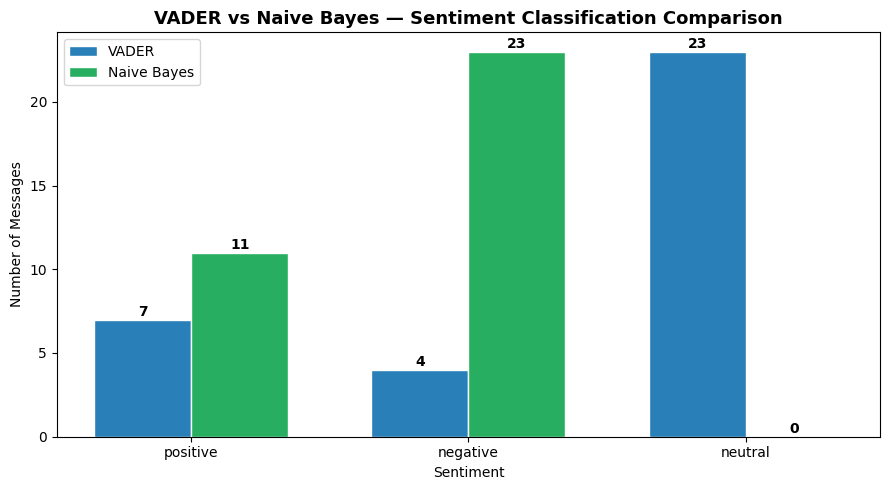


Note: Naive Bayes does not output 'neutral' — only positive/negative.
VADER uses a compound score threshold to determine neutral messages.


In [83]:
print("MODEL COMPARISON — VADER vs NAIVE BAYES")
print("=" * 55)
print(f"{'Message':<35} {'VADER':<12} {'NB':<12}")
print("-" * 55)
for _, row in df_chat.head(15).iterrows():
    msg = row['message'][:32] + "..." if len(row['message']) > 32 else row['message']
    print(f"{msg:<35} {row['vader_sentiment']:<12} {row['nb_sentiment']:<12}")

vader_counts = df_chat['vader_sentiment'].value_counts()
nb_counts = df_chat['nb_sentiment'].value_counts()

categories = ['positive', 'negative', 'neutral']
vader_vals = [vader_counts.get(c, 0) for c in categories]
nb_vals = [nb_counts.get(c, 0) for c in categories]

x = range(len(categories))
width = 0.35

plt.figure(figsize=(9, 5))
bars1 = plt.bar([i - width/2 for i in x], vader_vals,
                width, label='VADER', color='#2980b9', edgecolor='white')
bars2 = plt.bar([i + width/2 for i in x], nb_vals,
                width, label='Naive Bayes', color='#27ae60', edgecolor='white')

plt.title('VADER vs Naive Bayes — Sentiment Classification Comparison',
          fontsize=13, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Number of Messages')
plt.xticks(x, categories)
plt.legend()

for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             str(int(bar.get_height())), ha='center', fontweight='bold')
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             str(int(bar.get_height())), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("chat2_chart5_model_comparison.png", bbox_inches='tight')
plt.show()

print("\nNote: Naive Bayes does not output 'neutral' — only positive/negative.")
print("VADER uses a compound score threshold to determine neutral messages.")

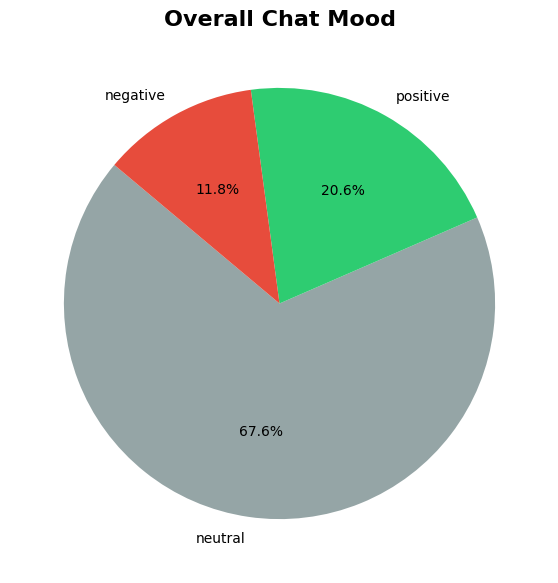

Chart 1 saved.


In [84]:
sentiment_counts = df_chat['vader_sentiment'].value_counts()

colors = []
for label in sentiment_counts.index:
    if label == 'positive':
        colors.append('#2ecc71')
    elif label == 'negative':
        colors.append('#e74c3c')
    else:
        colors.append('#95a5a6')

plt.figure(figsize=(7, 7))
plt.pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140
)
plt.title("Overall Chat Mood", fontsize=16, fontweight='bold')
plt.savefig("2nd chat_chart1_overall_mood.png", bbox_inches='tight')
plt.show()
print("Chart 1 saved.")

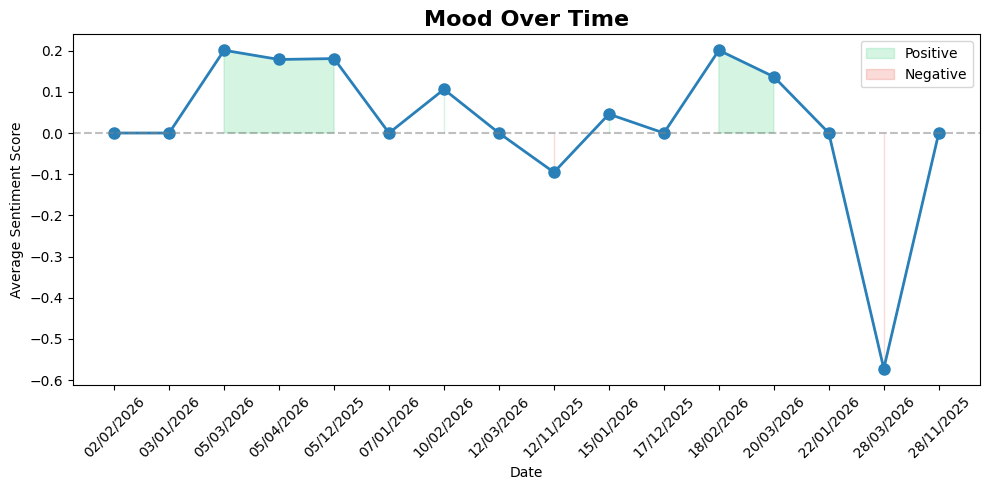

Chart 2 saved.


In [85]:
daily_mood = df_chat.groupby('date')['vader_score'].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(
    daily_mood['date'],
    daily_mood['vader_score'],
    marker='o', color='#2980b9', linewidth=2, markersize=8
)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.fill_between(
    daily_mood['date'],
    daily_mood['vader_score'],
    0,
    where=[s > 0 for s in daily_mood['vader_score']],
    color='#2ecc71', alpha=0.2, label='Positive'
)
plt.fill_between(
    daily_mood['date'],
    daily_mood['vader_score'],
    0,
    where=[s < 0 for s in daily_mood['vader_score']],
    color='#e74c3c', alpha=0.2, label='Negative'
)
plt.title("Mood Over Time", fontsize=16, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Average Sentiment Score")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("2nd chat_chart2_mood_over_time.png", bbox_inches='tight')
plt.show()
print("Chart 2 saved.")

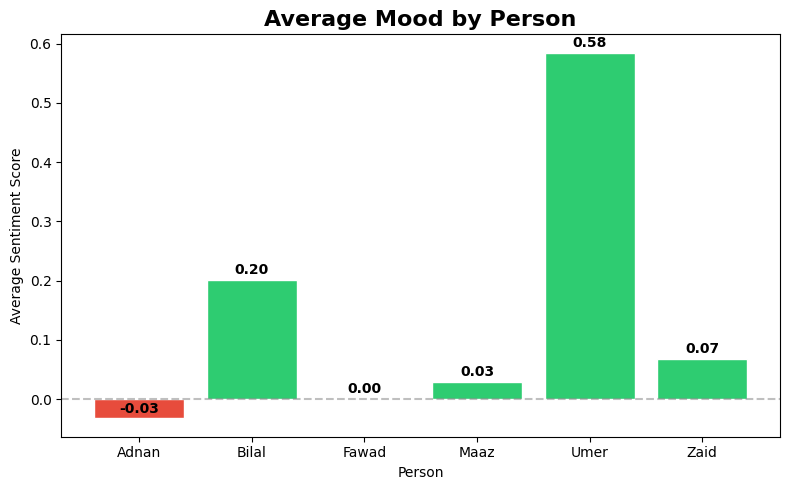

Chart 3 saved.


In [86]:
person_mood = df_chat.groupby('sender')['vader_score'].mean()

colors = ['#2ecc71' if s > 0 else '#e74c3c' for s in person_mood.values]

plt.figure(figsize=(8, 5))
bars = plt.bar(person_mood.index, person_mood.values, color=colors, edgecolor='white')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.title("Average Mood by Person", fontsize=16, fontweight='bold')
plt.xlabel("Person")
plt.ylabel("Average Sentiment Score")

for bar, val in zip(bars, person_mood.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{val:.2f}',
        ha='center', fontweight='bold'
    )

plt.tight_layout()
plt.savefig("2nd chat_chart3_mood_by_person.png", bbox_inches='tight')
plt.show()
print("Chart 3 saved.")

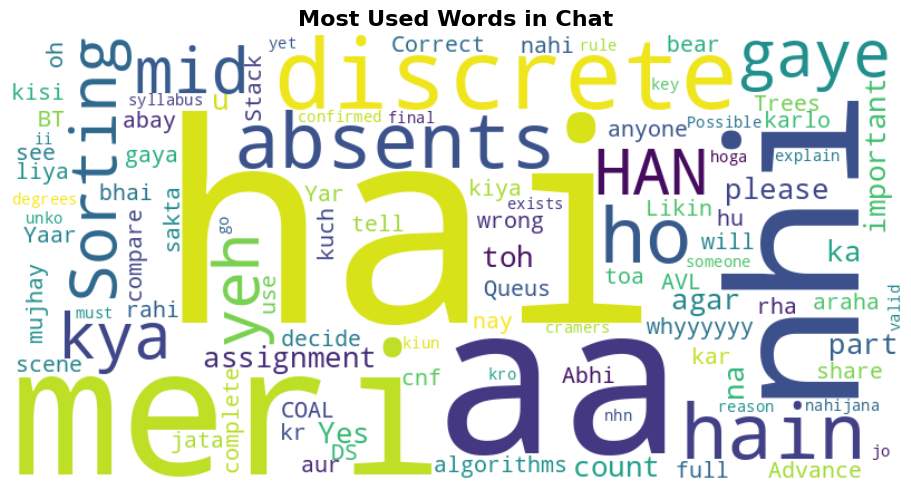

Chart 4 saved.


In [87]:
all_text = ' '.join(df_chat['message'].tolist())

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis',
    max_words=100
).generate(all_text)

plt.figure(figsize=(13, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Used Words in Chat", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("2nd chat_chart4_wordcloud.png", bbox_inches='tight')
plt.show()
print("Chart 4 saved.")

In [88]:
print("=" * 50)
print(" 'Parhai' WHATSAPP group CHAT MOOD ANALYSIS REPORT")
print("=" * 50)

total = len(df_chat)
pos = (df_chat['vader_sentiment'] == 'positive').sum()
neg = (df_chat['vader_sentiment'] == 'negative').sum()
neu = (df_chat['vader_sentiment'] == 'neutral').sum()

print(f"\nTotal Messages Analyzed: {total}")
print(f"Positive Messages: {pos} ({pos/total*100:.1f}%)")
print(f"Negative Messages: {neg} ({neg/total*100:.1f}%)")
print(f"Neutral Messages:  {neu} ({neu/total*100:.1f}%)")

print(f"\nMost Positive Person: {person_mood.idxmax()}")
print(f"Most Negative Person: {person_mood.idxmin()}")

print(f"\nNaive Bayes Model Accuracy: {accuracy*100:.2f}%")
print("\nAll 4 charts saved successfully.")
print("=" * 50)

 'Parhai' WHATSAPP group CHAT MOOD ANALYSIS REPORT

Total Messages Analyzed: 34
Positive Messages: 7 (20.6%)
Negative Messages: 4 (11.8%)
Neutral Messages:  23 (67.6%)

Most Positive Person: Umer
Most Negative Person: Adnan

Naive Bayes Model Accuracy: 85.06%

All 4 charts saved successfully.
